## Question 1: Regression Analysis & Data Preprocessing – Business and Housing Use Cases

### Scenario

You are working as a data analyst for a **real estate team** that wants to predict house prices using multiple factors.

You must clean, preprocess, analyze, and model the data appropriately.

### Datasets

* **House Prices Dataset (Multiple Linear Regression – Kaggle)**
  [https://www.kaggle.com/datasets/camnugent/california-housing-prices](https://www.kaggle.com/datasets/camnugent/california-housing-prices)

### Tasks

1. Perform **EDA** on datasets.
2. Apply required **data preprocessing** steps:

   * Handling missing values
   * Feature encoding (if applicable)
   * Feature scaling
4. Build a **Multiple Linear Regression** model for the housing dataset.
5. Interpret regression coefficients in real-world terms.
6. Evaluate model using **R²**, **MSE**, and residual analysis.
7. State and verify assumptions of linear regression.

___
___

About the dataset:
1. longitude: A measure of how far west a house is; a higher value is farther west
2. latitude: A measure of how far north a house is; a higher value is farther north
3. housingMedianAge: Median age of a house within a block; a lower number is a newer building
4. totalRooms: Total number of rooms within a block
5. totalBedrooms: Total number of bedrooms within a block
6. population: Total number of people residing within a block
7. households: Total number of households, a group of people residing within a home unit, for a block
8. medianIncome: Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. medianHouseValue: Median house value for households within a block (measured in US Dollars)
10. oceanProximity: Location of the house w.r.t ocean/sea

___
___

# EDA

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [21]:
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [22]:
df.shape

(20640, 10)

There are 10 feature columns and 20640 individual data enteries(rows)

In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


Among 10 columns 9 are float and one is string.
* Most columns have complete data; total_bedrooms has 20,433 non-null values, so 207 records are missing.

In [24]:
df.duplicated().sum()

np.int64(0)

No duplicated rows were found in the dataset.

In [25]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Descriptive Summary of the California Housing Dataset

The California Housing dataset contains **20,640 records** describing different housing blocks in California.

- **Housing Age:** The median housing age is **29 years**, while the average age is **28.64 years**. The ages range from **1 to 52 years**.

- **Rooms and Bedrooms:** Each block has an average of approximately **2,636 rooms** and **538 bedrooms**. The `total_bedrooms` column contains **207 missing values**.

- **Population and Households:** On average, each block has around **1,425 people** and **500 households**.

- **Median Income:** The average median income is **3.87**, which corresponds to approximately **$38,700**. The median income is **3.53**, or about **$35,300**.

- **House Value:** The average house value is approximately **$206,856**, while the median is **$179,700**. Since the mean is higher than the median, the house values show a **right-skewed distribution**. The maximum value of **$500,001** is capped in this dataset.

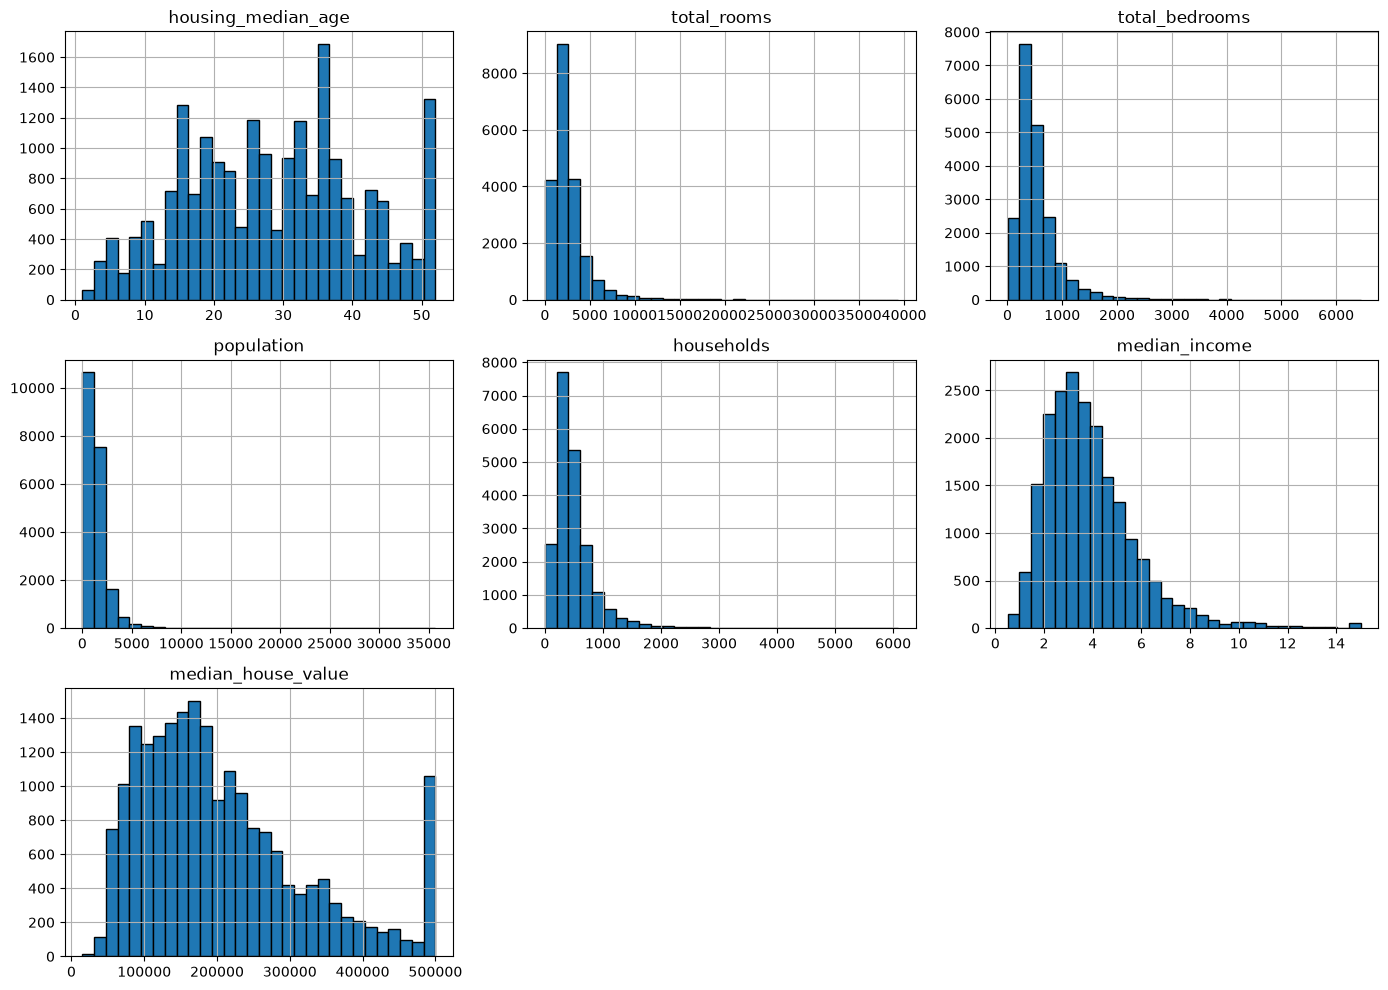

In [26]:
cols = [
    "housing_median_age", "total_rooms", "total_bedrooms",
    "population", "households", "median_income",
    "median_house_value"
]

df[cols].hist(bins=30, figsize=(14, 10), edgecolor="black")
plt.tight_layout()
plt.show()

## Histogram Analysis

The histograms indicate that most of the numerical features have a **right-skewed distribution**. This means that most observations are concentrated toward the lower values, while a smaller number of observations have much larger values, creating a long tail on the right side.

- **Housing Median Age:** The values range from approximately **1 to 52 years**. The distribution has multiple peaks, with a noticeable concentration of houses around **50 years** of age.

- **Total Rooms:** The distribution is **strongly right-skewed**. Most districts contain a relatively small number of rooms, while a few districts have exceptionally large numbers of rooms.

- **Total Bedrooms:** This feature is also **highly right-skewed**. Most observations have fewer bedrooms, while a small number of districts have very large bedroom counts.

- **Population:** The population distribution is **right-skewed**, with most districts having smaller populations and a few districts containing significantly larger populations.

- **Households:** The number of households follows a similar **right-skewed pattern**, where most districts have fewer households and only a few have very high values.

- **Median Income:** Most income values are concentrated between approximately **2 and 6**. The distribution has a noticeable tail toward higher income levels.

- **Median House Value:** Most house values are concentrated between approximately **$100,000 and $300,000**. The distribution has a right tail, while the large spike around **$500,000** indicates that the values are likely capped at this level.

<Axes: xlabel='ocean_proximity'>

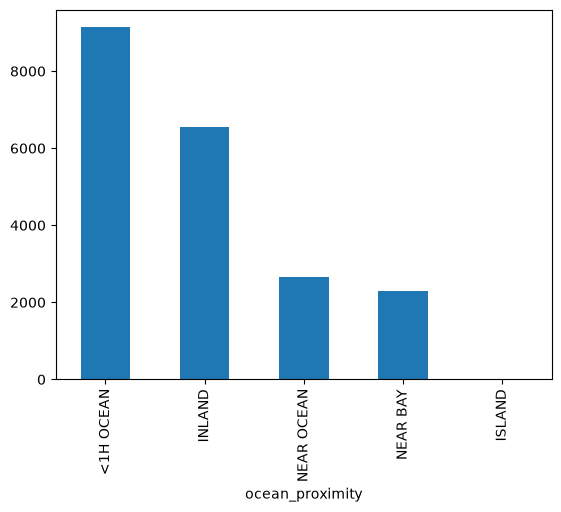

In [27]:
df.ocean_proximity.value_counts().plot(kind = "bar")

<Axes: >

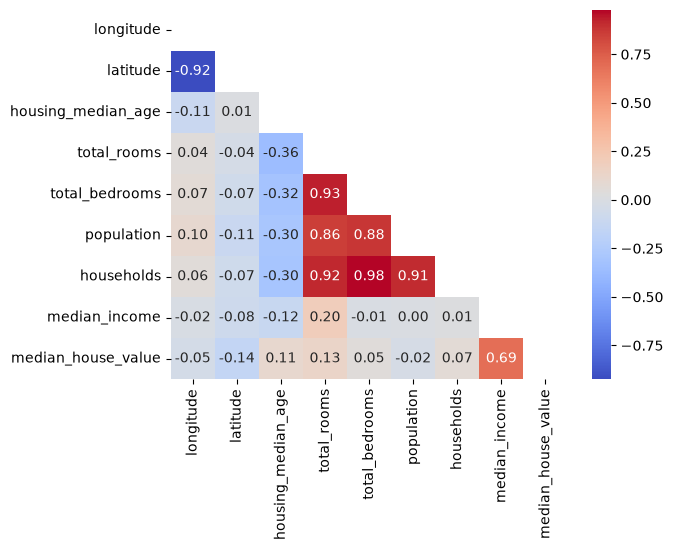

In [28]:
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot = True , fmt = ".2f", cmap = "coolwarm", mask= mask)

Median income for households within a block of houses (measured in tens of thousands of US Dollars) has a positive correlation with Median house value for households within a block (measured in US Dollars)

* total_rooms and households are strongly related (0.92), as are total_bedrooms and households (0.98). These features share overlapping information, so we could compress a pair into one feature—for example, use rooms per household (total_rooms / households) to represent average household size in rooms.

___
___

# Data Preprocessing

In [29]:
df.fillna({"total_bedrooms": df.total_bedrooms.median()}, inplace =True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[["median_income", "median_house_value"]] = scaler.fit_transform(
    df[["median_income", "median_house_value"]]
)

In [31]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,2.344766,2.129631,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,2.332238,1.314156,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,1.782699,1.258693,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,0.932968,1.165100,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,-0.012881,1.172900,NEAR BAY


In [32]:
df.corr(numeric_only= True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069120,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066484,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.319026,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927058,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069120,-0.066484,-0.319026,0.927058,1.000000,0.873535,0.974366,-0.007617,0.049457
population,0.099773,-0.108785,-0.296244,0.857126,0.873535,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974366,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007617,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049457,-0.024650,0.065843,0.688075,1.000000


<Axes: >

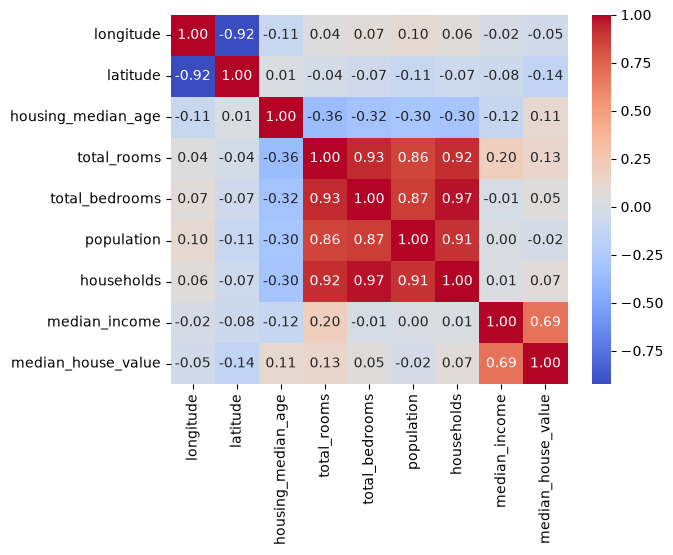

In [33]:
sns.heatmap(data = df.corr(numeric_only= True) ,annot = True, cmap = "coolwarm", fmt = ".2f")

In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df.drop("median_house_value", axis=1)

X_vif = X.select_dtypes(include=["int64", "float64"]).copy()

# Remove missing values
X_vif = X_vif.dropna()

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns

vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

print(vif)

              Feature        VIF
0           longitude   8.703623
1            latitude   8.826607
2  housing_median_age   1.259064
3         total_rooms  12.126382
4      total_bedrooms  26.882085
5          population   6.261680
6          households  28.284141
7       median_income   1.688920


In [35]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [37]:
X = df.drop(columns = "median_house_value")
y = df["median_house_value"]

In [38]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

C:\Users\shahh\AppData\Local\Temp\ipykernel_17776\3905257628.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns


In [39]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 0.43911517253428856
MSE : 0.36862871202499936
RMSE: 0.6071480149230494
R²  : 0.6254240620553633


In [40]:
residuals = y_test - y_pred

print(residuals.head())

20046   -0.055077
3024    -0.679638
15663    2.118950
20484   -0.428124
9814     0.131989
Name: median_house_value, dtype: float64


"The original dataset contained substantial multicollinearity among several count-based features, particularly total_rooms, total_bedrooms, and households. The engineered ratio features had relatively low VIF values, indicating that they did not introduce substantial multicollinearity. However, adding these engineered features did not improve the model's test-set performance."

Thus no feature were added to the original dataset.

___
___

# Assumptions of Linear Regression

Before using a Linear Regression model, we should check whether some important assumptions are satisfied.

## 1. Linearity

There should be an approximately **linear relationship between the input features (X) and the target (y)**.

**Check using:**
- Residual vs Predicted plot
- Randomly scattered residuals → good
- Curved pattern → possible problem

---

## 2. Independence

Each observation should be **independent of the others**.

For example, one house's price should not directly depend on another house's price.

**Check using:**
- Understanding how the data was collected
- Autocorrelation checks for time-series data

---

## 3. Homoscedasticity

The residuals should have a **roughly constant spread** for different predicted values.

**Check using:**
- Residual vs Predicted plot
- Constant spread → good
- Funnel-shaped pattern → possible heteroscedasticity

---

## 4. Normality of Residuals

The residuals should be **approximately normally distributed**.

This is especially important for statistical inference.

**Check using:**
- Histogram
- Q-Q plot

> Note: Linear Regression can still be useful when residuals are not perfectly normal. Normality is more important for statistical inference than for making predictions.

---

## 5. No Severe Multicollinearity

The independent variables should not be **too strongly related to each other**.

For example:

`House Area ↔ Number of Rooms`

These variables may contain similar information.

**Check using:**
- Correlation matrix
- VIF (Variance Inflation Factor)

---

## 6. No Highly Influential Outliers

A few unusual observations should not have an **unreasonably large effect** on the regression model.

**Check using:**
- Residuals
- Standardized residuals
- Cook's Distance

If outliers are present, investigate them instead of automatically removing them.

---

# Quick Summary

| Assumption | Meaning | How to Check |
|---|---|---|
| **Linearity** | X and y have a linear relationship | Residual plot |
| **Independence** | Observations are independent | Data structure |
| **Homoscedasticity** | Error spread is constant | Residual plot |
| **Normality** | Residuals are approximately normal | Histogram / Q-Q plot |
| **Multicollinearity** | Features aren't too highly related | VIF / Correlation |
| **Influential Outliers** | No observation dominates the model | Cook's Distance |

### Easy Way to Remember

**Linear → Independent → Constant Error → Normal Residuals → Low Multicollinearity → No Influential Outliers**